In [ ]:
import math
import numpy as np  
from download_mnist import load
import operator  
import time
from sklearn.neighbors import KNeighborsClassifier
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from download_mnist import load  

In [ ]:
x_train, y_train, x_test, y_test = load()
x_train = x_train.reshape(60000,28,28)
x_test  = x_test.reshape(10000,28,28)
x_train = x_train.astype(float)
x_test = x_test.astype(float)

In [ ]:
# # Load the MNIST dataset
# x_train, y_train, x_test, y_test = load()
# x_train = x_train.reshape(60000, 28*28).astype(np.float32)
# x_test = x_test.reshape(10000, 28*28).astype(np.float32)

In [4]:
# Display dataset details
print("MNIST Dataset Details:")
print("-" * 30)

# Training Data
print(f"Training Images: {x_train.shape} (Samples, Height, Width)")
print(f"Training Labels: {y_train.shape} (Samples)")

# Test Data
print(f"Test Images: {x_test.shape} (Samples, Height, Width)")
print(f"Test Labels: {y_test.shape} (Samples)")

# Data Type Information
print("\nData Type Information:")
print(f"x_train dtype: {x_train.dtype}, x_test dtype: {x_test.dtype}")
print(f"y_train dtype: {y_train.dtype}, y_test dtype: {y_test.dtype}")

# Min-Max Values
print("\nPixel Intensity Ranges:")
print(f"Train Images: Min={x_train.min()}, Max={x_train.max()}")
print(f"Test Images: Min={x_test.min()}, Max={x_test.max()}")

# Unique Labels in Dataset
print("\nUnique Labels in Training Set:", np.unique(y_train))
print("Unique Labels in Test Set:", np.unique(y_test))

# Example of a single image shape and label
print("\nSample Image Shape:", x_train[0].shape)
print("Sample Label:", y_train[0])

MNIST Dataset Details:
------------------------------
Training Images: (60000, 784) (Samples, Height, Width)
Training Labels: (60000,) (Samples)
Test Images: (10000, 784) (Samples, Height, Width)
Test Labels: (10000,) (Samples)

Data Type Information:
x_train dtype: float32, x_test dtype: float32
y_train dtype: uint8, y_test dtype: uint8

Pixel Intensity Ranges:
Train Images: Min=0.0, Max=255.0
Test Images: Min=0.0, Max=255.0

Unique Labels in Training Set: [0 1 2 3 4 5 6 7 8 9]
Unique Labels in Test Set: [0 1 2 3 4 5 6 7 8 9]

Sample Image Shape: (784,)
Sample Label: 9


In [7]:
def kNNClassify(newInput, dataSet, labels, k, distance_metric='euclidean'):
    """
    Scikit-Learn optimized k-Nearest Neighbors (kNN) classifier with L1 & L2 distance options.
    """
    knn = KNeighborsClassifier(n_neighbors=k, metric=distance_metric, algorithm='auto', n_jobs=-1)
    knn.fit(dataSet, labels)  # Train KNN model
    return knn.predict(newInput)  # Predict labels for test samples

KNN (k=1, euclidean distance) took 10.60 seconds
Accuracy: 0.8497

KNN (k=1, manhattan distance) took 130.83 seconds
Accuracy: 0.8526

KNN (k=2, euclidean distance) took 10.12 seconds
Accuracy: 0.8460

KNN (k=2, manhattan distance) took 133.74 seconds
Accuracy: 0.8523

KNN (k=3, euclidean distance) took 13.30 seconds
Accuracy: 0.8541

KNN (k=3, manhattan distance) took 133.23 seconds
Accuracy: 0.8575

KNN (k=4, euclidean distance) took 11.58 seconds
Accuracy: 0.8577

KNN (k=4, manhattan distance) took 136.52 seconds
Accuracy: 0.8580

KNN (k=5, euclidean distance) took 11.48 seconds
Accuracy: 0.8554

KNN (k=5, manhattan distance) took 134.27 seconds
Accuracy: 0.8623

KNN (k=6, euclidean distance) took 9.88 seconds
Accuracy: 0.8544

KNN (k=6, manhattan distance) took 133.97 seconds
Accuracy: 0.8623


=== Hyperparameter Tuning Results ===
K=1, Distance=euclidean, Accuracy=0.8497
K=1, Distance=manhattan, Accuracy=0.8526
K=2, Distance=euclidean, Accuracy=0.8460
K=2, Distance=manhattan, Accu

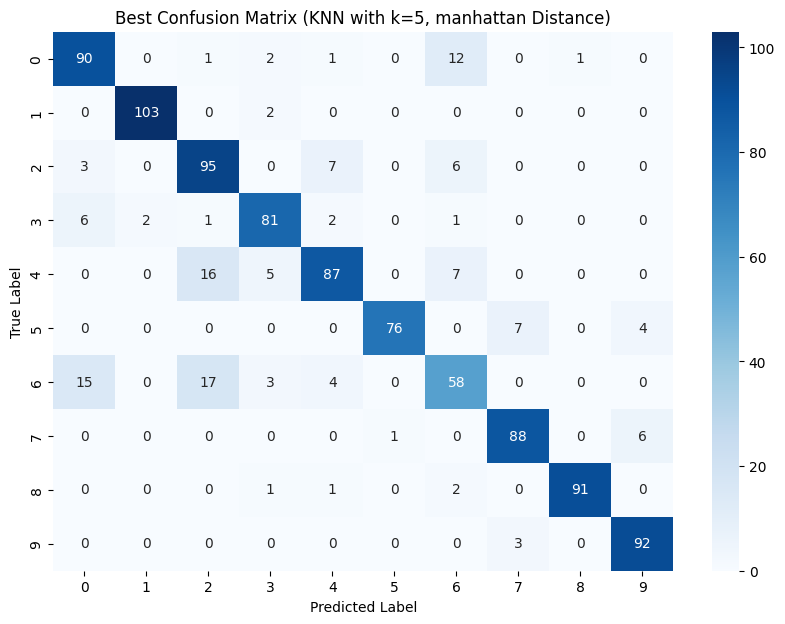

In [6]:
# Hyperparameters to test
k_values = [1, 2, 3, 4, 5, 6]
distance_metrics = ['euclidean', 'manhattan']
best_accuracy = 0
best_k = None
best_metric = None
results = []

# Run KNN with different hyperparameters
for k in k_values:
    for metric in distance_metrics:
        start = time.time()
        y_pred = kNNClassify(x_test, x_train, y_train, k, metric)  # Test on full dataset
        accuracy = accuracy_score(y_test, y_pred)  # Compare against full test labels
        end = time.time()

        # Evaluate performance
        conf_matrix = confusion_matrix(y_test, y_pred)

        # Store results
        results.append((k, metric, accuracy))

        print(f"KNN (k={k}, {metric} distance) took {end - start:.2f} seconds")
        print(f"Accuracy: {accuracy:.4f}\n")
        
        # Track best model
        if accuracy > best_accuracy:
            best_accuracy = accuracy
            best_k = k
            best_metric = metric

# Print all results
print("\n=== Hyperparameter Tuning Results ===")
for k, metric, acc in results:
    print(f"K={k}, Distance={metric}, Accuracy={acc:.4f}")

# Print best performing model
print("\n=== Best Model ===")
print(f"Best K: {best_k}")
print(f"Best Distance Metric: {best_metric}")
print(f"Best Accuracy: {best_accuracy:.4f}")

# Plot confusion matrix for best model
print("\nGenerating Confusion Matrix for Best Model...")
y_pred_best = kNNClassify(x_test[:1000], x_train, y_train, best_k, best_metric)
conf_matrix_best = confusion_matrix(y_test[:1000], y_pred_best)

plt.figure(figsize=(10, 7))
sns.heatmap(conf_matrix_best, annot=True, fmt="d", cmap="Blues", xticklabels=range(10), yticklabels=range(10))
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title(f"Best Confusion Matrix (KNN with k={best_k}, {best_metric} Distance)")
plt.show()

In [9]:
start_time = time.time()
outputlabels=kNNClassify(x_test[0:20],x_train,y_train,10)
result = y_test[0:20] - outputlabels
result = (1 - np.count_nonzero(result)/len(outputlabels))
print ("---classification accuracy for knn on mnist: %s ---" %result)
print ("---execution time: %s seconds ---" % (time.time() - start_time))

---classification accuracy for knn on mnist: 0.85 ---
---execution time: 0.19602727890014648 seconds ---
